 # Complete Time Series Forecasting Cheat Sheet



 ## 1. Introduction & Core Components

 Forecasting relies on using historical data to project future values. Two main limitations exist:

 1. **Noise vs. Patterns:** Difficult to distinguish random fluctuations from meaningful patterns, leading to potential overfitting.

 2. **Structural Changes:** Historical trends are not guaranteed to continue due to external disruptions (economic, geopolitical, etc.).



 ### The 4 Components of Time Series Data

 * **Trend Component:** The long-term direction of the data (linear or nonlinear upward/downward drift).

 * **Seasonal Component:** Regular patterns that repeat over a fixed, known calendar period (e.g., monthly, quarterly).

 * **Cyclical Component:** Fluctuations over longer, irregular periods (e.g., economic expansions/recessions). Unlike seasonal patterns, cycles vary in length and intensity.

 * **Random (Noise) Component:** Unpredictable variations, errors, or random shocks giving the data its jagged appearance.

In [1]:
# Package Imports
import numpy as np                                  # Scientific computing
import pandas as pd                                 # Dataframe manipulation
import scipy.stats as stats                         # Statistical tests
import matplotlib.pyplot as plt                     # Basic visualization
import seaborn as sns                               # Advanced data visualization
from sklearn.linear_model import LinearRegression   # Linear regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

            number_of_heavily_wounded
date                                 
2013-01-01                        285
2013-02-01                        276
2013-03-01                        332
2013-04-01                        381
2013-05-01                        393


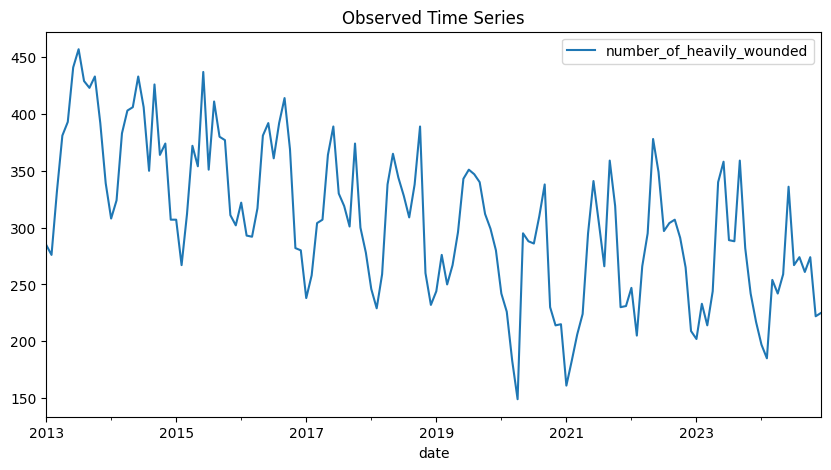

In [2]:
# Read data, parse dates, and explicitly set Month Start ('MS') frequency
url = 'https://raw.githubusercontent.com/HoGentTIN/dsai-labs/refs/heads/main/data/number_of_heavily_wounded_car_accidents_BE.txt'
wounded_data = pd.read_csv(url, delimiter="\t", parse_dates=['date']).set_index(['date'])
wounded_data.index = pd.DatetimeIndex(wounded_data.index, freq='MS')

# Display initial data
print(wounded_data.head())
wounded_data.plot(y='number_of_heavily_wounded', figsize=[10,5], title="Observed Time Series");
plt.show()


 ## 2. Evaluation Metrics & Chronological Train-Test Split

 To evaluate accuracy, we compute **Mean Absolute Error (MAE)** and **Mean Squared Error (MSE)**.

 * **MAE:** Measures average absolute distance. Easy to interpret as it retains data units:

 $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

 * **MSE:** Squares errors, heavily penalizing larger deviations/outliers:

 $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$



 ⚠️ **CRITICAL:** Standard random shuffling breaks temporal dependencies and causes **data leakage**. Time series splits must always be performed **chronologically**.

In [3]:
# Chronological Train-Test Split
# Train: historical data up to end of 2023. Test: all data from 2024.
train = wounded_data[:'2023-12-01']
test = wounded_data['2024-01-01':]

y_true = test['number_of_heavily_wounded'].values
print(f"Test Set Size: {len(y_true)} months")


Test Set Size: 12 months


 ## 3. Forecasting Models



 ### Model 1: Constant Model (Horizontal Line)

 Assumes data fluctuates around a stable, constant mean with random noise:

 $$y_t = b_0 + \epsilon_t$$

 * **Pros:** Simple benchmark; removes noise by averaging historical values.

 * **Cons:** Fails to capture trends or seasonal cycles.

In [4]:
# Estimate mean using a specified history span (e.g., first 80 values)
b_est_80 = wounded_data['number_of_heavily_wounded'][:80].mean()
print(f"Constant Baseline Estimate: {b_est_80:.3f}")

# Calculate MAE for 2024 based on overall training average baseline
y_pred_constant = [train['number_of_heavily_wounded'].mean()] * len(y_true)
mae_constant = mean_absolute_error(y_true, y_pred_constant)
print(f"Constant Model MAE: {mae_constant:.3f}")


Constant Baseline Estimate: 338.925
Constant Model MAE: 65.936


 ### Model 2: Linear Trend Model (Simple Linear Regression)

 Models data evolving linearly over time:

 $$y_t = b_0 + b_1 \cdot t + \epsilon_t$$

 * $b_0$: Intercept (expected series value at $t = 0$).

 * $b_1$: Slope/Trend (expected change from one period to the next). Negative $b_1$ proves a descending trend.

 * **Shortcoming:** Assumes a permanent linear path and ignores seasonality completely.

In [5]:
# Approach A: Linear Regression using np.polyfit
y_train = train['number_of_heavily_wounded'].values
x_train = np.arange(len(y_train))
b1, b0 = np.polyfit(x=x_train, y=y_train, deg=1)
print(f"Regression Line Equation: ŷ = {b0:.3f} + ({b1:.3f}) * t")

# Generate predictions for the 2024 test timeline (indices follow training sequence length)
x_test = np.arange(len(y_train), len(y_train) + len(y_true))
y_pred_lr = b0 + b1 * x_test

mae_lr = mean_absolute_error(y_true, y_pred_lr)
print(f"Linear Trend Model MAE: {mae_lr:.3f}")


Regression Line Equation: ŷ = 376.787 + (-0.996) * t
Linear Trend Model MAE: 31.618


 ### Model 3: Simple Moving Average (SMA)

 A rolling window approach taking the mean of the last $m$ observations:

 $$\hat{y}_{t+1} = \frac{1}{m} \sum_{i=t-m+1}^{t} y_i$$

 * Larger windows ($m$) yield a smoother forecast less sensitive to extremes. Small windows respond quickly but retain noise.

 * ⚠️ **Data Leakage Fix:** You must use `.shift(1)` to move results forward one step so that the prediction at time $t$ uses only past information ($t-1, t-2, \dots$).

 * Use `min_periods=1` inside `.rolling()` if you wish to fill initial `NaN` empty cells.

In [13]:
# Calculate valid lagging predictions using shift(1)
wounded_data['SMA3'] = wounded_data['number_of_heavily_wounded'].rolling(3).mean().shift(1)
wounded_data['SMA5'] = wounded_data['number_of_heavily_wounded'].rolling(5).mean().shift(1)
wounded_data['SMA10'] = wounded_data['number_of_heavily_wounded'].rolling(10).mean().shift(1)

# Multiple SMAs
for i in [3, 5, 10]:
    wounded_data[f'SMA{i}'] = wounded_data['number_of_heavily_wounded'].rolling(i).mean().shift(1)

# Evaluate performance on test data
mae_3 = mean_absolute_error(y_true, wounded_data['SMA3'][-12:].values)
mae_5 = mean_absolute_error(y_true, wounded_data['SMA5'][-12:].values)
mae_10 = mean_absolute_error(y_true, wounded_data['SMA10'][-12:].values)
print(f"SMA3 MAE: {mae_3:.3f} | SMA5 MAE: {mae_5:.3f} | SMA10 MAE: {mae_10:.3f}")


SMA3 MAE: 35.222 | SMA5 MAE: 40.433 | SMA10 MAE: 38.008


 ### Model 4: Simple Exponential Smoothing (SES)

 Calculates a level estimate where weights assigned to past observations drop exponentially over time. Suitable for data with **no clear trend and no seasonality**.



 * **Level Update ($L_t$):** $L_t = \alpha y_t + (1 - \alpha) L_{t-1}$

 * **Forecast Calculation:** $\hat{y}_{t+k} = L_t$ (Flat forecast line into the future)

 * $\alpha$ (Smoothing constant) ranges between $0$ and $1$. Near $0 \rightarrow$ historical values retain heavy influence (smooth). Near $1 \rightarrow$ reacts immediately to recent shifts.

In [7]:
# Fit SES model on complete series
data_ses = SimpleExpSmoothing(wounded_data['number_of_heavily_wounded']).fit(smoothing_level=0.1, optimized=False)
wounded_data['SES'] = data_ses.level
# .fittedvalues gives the step-ahead model predictions natively without manual shifting
wounded_data['SES_predicted_value'] = data_ses.fittedvalues

# Manual verification check of level calculation logic:
alpha = 0.1
manual_level = alpha * 276 + (1 - alpha) * 285 
print(f"Manual check: {manual_level} | Model output: {wounded_data['SES'].iloc[1]}")

# Forecast step & Test split evaluation
data_ses = SimpleExpSmoothing(train['number_of_heavily_wounded']).fit(smoothing_level=0.1, optimized=False)
y_pred_ses = [data_ses.level.iloc[-1]] * len(y_true)
print(f"SES Model MAE: {mean_absolute_error(y_true, y_pred_ses):.3f}")


Manual check: 284.1 | Model output: 284.1
SES Model MAE: 36.005


 ### Model 5: Double Exponential Smoothing (Holt’s Method)

 Introduces an explicit **trend** component alongside the level tracking variable. Suitable for data with a **trend, but no seasonality**.



 * **Level ($L_t$):** $L_t = \alpha y_t + (1 - \alpha)(L_{t-1} + T_{t-1})$

 * **Trend ($T_t$):** $T_t = \beta(L_t - L_{t-1}) + (1 - \beta)T_{t-1}$

 * **Forecast Equation:** $\hat{y}_{t+k} = L_t + k \cdot T_t$

 * $\beta$ represents the trend smoothing speed parameter.

In [8]:
# Fit Double Exponential Smoothing
data_des = Holt(wounded_data['number_of_heavily_wounded']).fit(smoothing_level=0.1, smoothing_trend=0.2, optimized=False)
wounded_data['DES'] = data_des.level
wounded_data['DES_fittedvalues'] = data_des.fittedvalues

# Evaluate Holt predictions on 2024 test data
data_des_train = Holt(train['number_of_heavily_wounded']).fit(smoothing_level=0.1, smoothing_trend=0.2, optimized=False)
last_DES_level = data_des_train.level.iloc[-1]
last_DES_trend = data_des_train.trend.iloc[-1]

# Forecast calculation step: y_pred = Level + k * Trend
y_pred_des = [last_DES_level + k * last_DES_trend for k in range(1, len(y_true) + 1)]
print(f"DES Model MAE: {mean_absolute_error(y_true, y_pred_des):.3f}")


DES Model MAE: 34.592


 ### Model 6: Triple Exponential Smoothing (Holt-Winters Method)

 Tracks **level ($L_t$)**, **trend ($T_t$)**, and **seasonal ($S_t$)** components simultaneously. Crucial for sequences displaying a recurring cycle.

 * **Additive Model Structure:** Fluctuation amplitudes stay relatively constant over time regardless of series scale levels.

   $$\hat{y}_{t+k} = L_t + k \cdot T_t + S_{t-m+k}$$

 * $m$ indicates cycle phase resolution limits (e.g., $12$ for full yearly monthly tracking cycles).

In [9]:
# Fit Triple Exponential Smoothing Model on training slice
data_tes = ExponentialSmoothing(train['number_of_heavily_wounded'], trend='add', seasonal='add', seasonal_periods=12, freq='MS').fit()
wounded_data['TES'] = data_tes.level

# Forecast 12 Months Out (Year 2024)
data_tes_forecast = data_tes.forecast(12)
mae_tes = mean_absolute_error(y_true, data_tes_forecast.values)
print(f"TES Model MAE: {mae_tes:.3f}")

# Verification of forecast matching formula math:
level_val = data_tes.level.iloc[-1]
trend_val = data_tes.trend.iloc[-1]
season_array = data_tes.season.iloc[-12:].values

# Recreate first month forecast manually: Level + 1 * Trend + Season_Index
jan_pred_manual = level_val + 1 * trend_val + season_array[0]
print(f"Manual math forecast: {jan_pred_manual:.3f} | Model output: {data_tes_forecast.values[0]:.3f}")


TES Model MAE: 20.580
Manual math forecast: 203.717 | Model output: 203.717


### Plotting

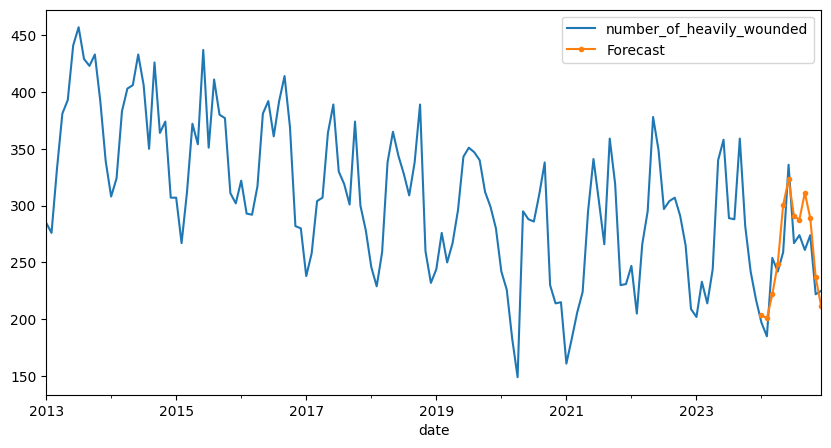

In [12]:
wounded_data.plot(y=['number_of_heavily_wounded'], figsize=[10,5])
data_tes_forecast.plot(marker='.', legend=True, label='Forecast');

 ## 4. Visual Time Series Decomposition

 Decomposition breaks down an active time series into separate graphical tracks representing the isolated patterns of its individual component dimensions:

 1. **Observed:** The raw time series.

 2. **Trend:** Smooth long-term trajectory.

 3. **Seasonal:** Stable cyclical patterns.

 4. **Residues (Residuals):** Extracted noise data component.

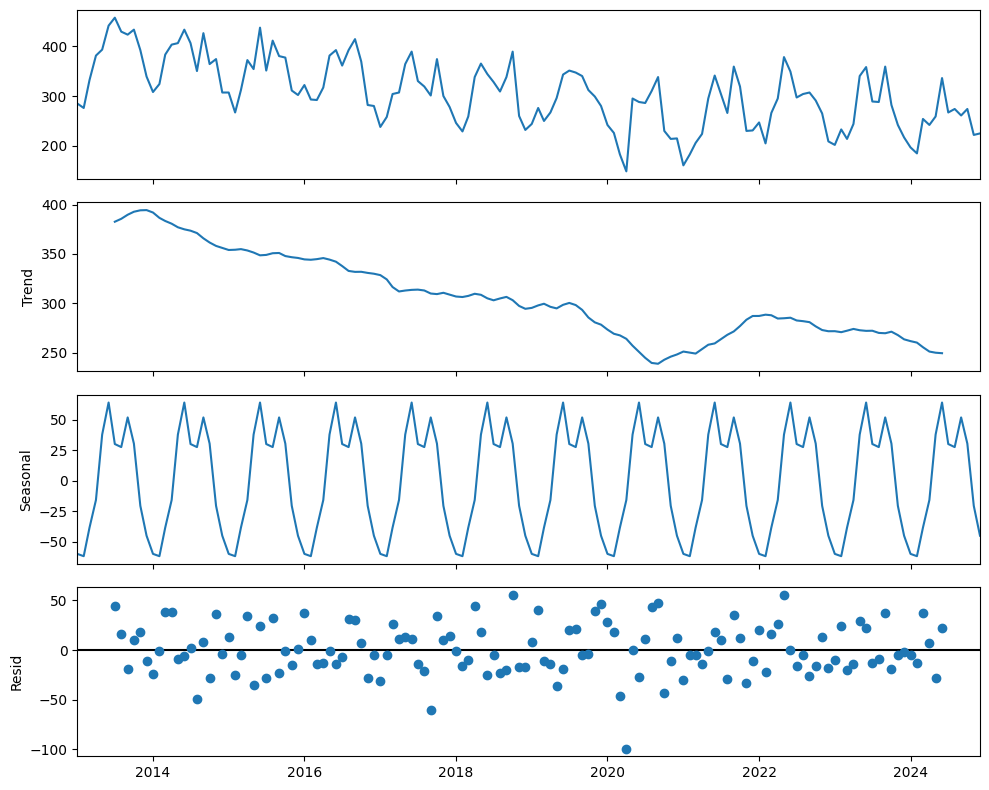

In [11]:
# Clean dataset to perform visual component isolation breakdown analysis
data_clean = wounded_data[['number_of_heavily_wounded']]
wounded_decomposed = seasonal_decompose(data_clean, model='additive')

# Plot structural tracks
fig = wounded_decomposed.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()